In [30]:
"""
=============================================================================
🛰️ Project 8 — Multipath Analysis
=============================================================================
 Author   : Hakim El Azzouzi
 Degree   : MSc Global Navigation Satellite Systems
            Mohammed First University, Oujda, Morocco
 Email    : elazzouzihakim10@gmail.com
 LinkedIn : https://linkedin.com/in/Hakim-El-Azzouzi
 Location : Luxembourg 🇱🇺
-----------------------------------------------------------------------------
 Station  : AUCK00NZL  —  Auckland, New Zealand  (GeoNet / LINZ Network)
 File     : AUCK00NZL_R_20260010000_01D_30S_MO.rnx
 Receiver : TRIMBLE ALLOY
 Antenna  : TRM115000.00
 Format   : RINEX 3.05  |  Mixed Constellations  |  30-second sampling
 Date     : 2026-01-01  (Day-of-Year 001)
-----------------------------------------------------------------------------
 Description
 -----------
Multipath is one of the most difficult GNSS error sources to model or eliminate.
It occurs when the GNSS signal arrives at the receiver via reflected paths in addition
to the direct path — from buildings, water surfaces, vehicles, or the ground.

Unlike ionospheric delay (removed with two frequencies) or tropospheric delay
(modelled with meteorological data), multipath is site-specific and unpredictable.

This project computes the MP1 and MP2 multipath proxies for all GPS satellites
and analyses when, where, and how severely multipath affects the AUCK00NZL station.

**5 plots produced:**

| Plot | What It Shows |
|------|---------------|
| 📉 **MP1 time series** | Multipath variation during each satellite's arc |
| 🌡️ **MP1 heatmap** | All GPS satellites — multipath intensity over time |
| 📊 **MP1 RMS bar chart** | Which satellites are most affected |
| 📈 **MP1 histogram** | Statistical distribution of multipath errors |
| 🕐 **Sidereal repeat** | Does multipath repeat 4 minutes earlier each day? |
---
## 📐 The Mathematics

### MP1 — L1 code multipath proxy:
```
MP1 = C1C − Φ₁ − α · (Φ₁ − Φ₂)
    = C1C − Φ₁ − [2f₂² / (f₁² − f₂²)] · (Φ₁ − Φ₂)
    ≈ MP_code + noise  +  constant(N₁, N₂, bias)
```

### MP2 — L2 code multipath proxy:
```
MP2 = C2W − Φ₂ − β · (Φ₁ − Φ₂)
    = C2W − Φ₂ − [2f₁² / (f₁² − f₂²)] · (Φ₁ − Φ₂)
    ≈ MP_code_L2 + noise  +  constant(N₁, N₂, bias)
```

Where:
- `C1C` = pseudorange on L1 C/A [metres]
- `Φ₁ = L1C × λ₁` = carrier phase on L1 [metres]
- `Φ₂ = L2W × λ₂` = carrier phase on L2 [metres]
- `f₁ = 1575.42 MHz`, `f₂ = 1227.60 MHz`
- `α = 2f₂²/(f₁²−f₂²) ≈ 1.5457`
- `β = 2f₁²/(f₁²−f₂²) ≈ 2.5457`

### After removing the mean (which contains ambiguity + ionosphere DC):
```
MP1 − mean(MP1) ≈ pure multipath + receiver noise
```

### Quality metric:
```
RMS(MP1) = sqrt(mean(MP1²))   [metres]

< 0.30 m  → clean site, very low multipath
0.30–0.50 m → moderate multipath
> 0.50 m  → high multipath (nearby reflectors)
```

### Sidereal repeat:
GPS satellites repeat their ground track every **sidereal day ≈ 23 h 56 min 4 s**
= 4 minutes shorter than a solar day.
Multipath patterns repeat at the same **sidereal time** each day — a powerful
property used in multipath mitigation (sidereal filtering).

---
-----------------------------------------------------------------------------
 **About the projects**
 ----------------------
# Step1: Install & Import Libraries
# Step2: Load the RINEX File
# Step3: Compute MP1 and MP2 for All GPS Satellites
# Step4: Plot 1: MP1 Time Series (Selected Satellites)
# Step5: Plot 2: MP1 Heatmap
# Step6: Plot 3: MP1 RMS Bar Chart (Satellite Ranking)
# Step7: Plot 4: MP1 Distribution Histogram
# Step8: Plot 5: Sidereal Repeat Check
=============================================================================
"""

"\n=============================================================================\n🛰️ Project 8 — Multipath Analysis\n=============================================================================\n Author   : Hakim El Azzouzi\n Degree   : MSc Global Navigation Satellite Systems\n            Mohammed First University, Oujda, Morocco\n Email    : elazzouzihakim10@gmail.com\n LinkedIn : https://linkedin.com/in/Hakim-El-Azzouzi\n Location : Luxembourg 🇱🇺\n-----------------------------------------------------------------------------\n Station  : AUCK00NZL  —  Auckland, New Zealand  (GeoNet / LINZ Network)\n File     : AUCK00NZL_R_20260010000_01D_30S_MO.rnx\n Receiver : TRIMBLE ALLOY\n Antenna  : TRM115000.00\n Format   : RINEX 3.05  |  Mixed Constellations  |  30-second sampling\n Date     : 2026-01-01  (Day-of-Year 001)\n-----------------------------------------------------------------------------\n Description\n -----------\nMultipath is one of the most difficult GNSS error sources to mode

In [4]:
pip install --upgrade georinex

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.7/73.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.7 MB/s eta 0:00:00


In [31]:
# ─────────────────────────────────────────────────────────────────
# Step 1 — Install & Import Libraries
# ─────────────────────────────────────────────────────────────────
# Uncomment if running for the first time:
# !pip install --upgrade georinex

import sys
sys.path.append('../../shared/utils')   # ← path to shared utilities

import georinex as gr
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.patches import Patch
import warnings
import os
os.makedirs('../content/output', exist_ok=True)

# ─────────────────────────────────────────────────────────────────
# Physical constants
# ─────────────────────────────────────────────────────────────────
C = 299_792_458.0        # speed of light [m/s]

# GPS
F1_GPS  = 1_575.42e6
F2_GPS  = 1_227.60e6
F5_GPS  = 1_176.45e6
LAM1_GPS = C / F1_GPS   # ≈ 0.19029 m
LAM2_GPS = C / F2_GPS   # ≈ 0.24421 m
LAM5_GPS = C / F5_GPS

CONST_COLORS = {
    'G': '#2196F3',   # GPS     — blue
    'R': '#F44336',   # GLONASS — red
    'E': '#4CAF50',   # Galileo — green
    'C': '#FF9800',   # BeiDou  — orange
    'J': '#9C27B0',   # QZSS    — purple
    'S': '#00BCD4',   # SBAS    — cyan
}
CONST_NAMES = {
    'G': 'GPS', 'R': 'GLONASS', 'E': 'Galileo',
    'C': 'BeiDou', 'J': 'QZSS', 'S': 'SBAS',
}
# Multipath coefficient for MP1
# MP1 = C1 - L1 - 2*(f2²/(f1²-f2²))*(L1-L2)
ALPHA_MP1_GPS = 2 * F2_GPS**2 / (F1_GPS**2 - F2_GPS**2)   # ≈ 1.5457

# L4 → STEC conversion [m/TECU] for GPS
ALPHA_IONO_GPS = 40.3e16 * (1/F1_GPS**2 - 1/F2_GPS**2)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120})

# MP2 coefficient  β = 2f₁²/(f₁²−f₂²)
ALPHA_MP2_GPS = 2 * F1_GPS**2 / (F1_GPS**2 - F2_GPS**2)   # ≈ 2.5457

# Cycle-slip threshold for arc splitting [metres]
CS_THRESH = 0.15
# ─────────────────────────────────────────────────────────────────
# Functions
# ─────────────────────────────────────────────────────────────────
# Plot styling helpers
def dark_style(ax):
    """Apply the standard dark GNSS theme to an Axes object."""
    ax.set_facecolor('#111827')
    ax.tick_params(colors='#aaaaaa')
    ax.grid(True, color='#222222', linewidth=0.5)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

def dark_legend(ax, **kwargs):
    """Add a dark-themed legend to an Axes object."""
    legend = ax.legend(
        framealpha=0.3,
        facecolor='#1a1a2e',
        edgecolor='#444444',
        **kwargs,
    )
    for text in legend.get_texts():
        text.set_color('white')
    return legend


print('✅ Libraries loaded')
print(f'   α (MP1) = {ALPHA_MP1_GPS:.4f}')
print(f'   β (MP2) = {ALPHA_MP2_GPS:.4f}')
print(f'   L1 wavelength = {LAM1_GPS*100:.4f} cm')
print(f'   L2 wavelength = {LAM2_GPS*100:.4f} cm')

✅ Libraries loaded
   α (MP1) = 3.0915
   β (MP2) = 5.0915
   L1 wavelength = 19.0294 cm
   L2 wavelength = 24.4210 cm


In [7]:
# ─────────────────────────────────────────────────────────────────
# Step 2 — Load the RINEX File
# ─────────────────────────────────────────────────────────────────
# RINEX FILE PATH HERE
obs_path = "/AUCK00NZL_R_20260010000_01D_30S_MO.rnx"  # ← change this path
# Read the file header first (fast — no data loaded yet)
print("📋 FILE HEADER")
print("=" * 60)
header = gr.rinexheader(obs_path)

for key, value in header.items():
    print(f"{key:<25}: {value}")

print()

# Load all observation data (interval=30 means keep 30-sec rate)

print("⏳ Loading observation data (this may take 1–2 minutes)...")
obs = gr.load(obs_path, interval=30)
print()
print("✅ Data loaded!")
print(obs)

📋 FILE HEADER
version                  : 3.05
filetype                 : O
rinextype                : obs
systems                  : M
PGM / RUN BY / DATE      : t0xConvert 02.37.00 t0xConvert Operator 20260102 000700 UTC 
COMMENT                  : gfzrnx-2.1.9        FILE MERGE          20260102 000711 UTC  INITIAL_RINEX_VERSION: 3.04                                                                                               This station is part of the LINZ and GeoNet cGNSS networks.  These networks are operated in partnership between Land      Information New Zealand and GNS Science.                     This data is licensed for re-use under the Creative Commons  Attribution 4.0 International licence. For more detail       please refer to https://www.linz.govt.nz/linz-copyright                                                                   GFZRNX.NUM_EPOCHS: 2880                                     
MARKER NAME              : AUCK00NZL                                           

In [8]:
# ────────────────────────────────────────────────────
# Step 3 — Compute MP1 and MP2 for All GPS Satellites
# ────────────────────────────────────────────────────
def compute_MP_arc_split(obs, sat, mp_type='MP1'):
    """
    Compute multipath proxy (MP1 or MP2) with arc splitting at cycle slips.

    For each continuous arc (no cycle slip), the DC offset (ambiguity +
    ionosphere) is removed by subtracting the arc mean.

    Parameters
    ----------
    obs     : xarray.Dataset
    sat     : str   — GPS satellite PRN
    mp_type : str   — 'MP1' (L1 code) or 'MP2' (L2 code)

    Returns
    -------
    mp : pd.Series or None — multipath proxy [metres]
    rms: float or None     — overall RMS [metres]
    """
    if mp_type == 'MP1':
        needed = ['C1C', 'L1C', 'L2W']
        alpha  = ALPHA_MP1_GPS
        c_code = 'C1C'
        p1_code, lam1 = 'L1C', LAM1_GPS
        p2_code, lam2 = 'L2W', LAM2_GPS
    else:   # MP2
        needed = ['C2W', 'L1C', 'L2W']
        alpha  = ALPHA_MP2_GPS
        c_code = 'C2W'
        p1_code, lam1 = 'L1C', LAM1_GPS
        p2_code, lam2 = 'L2W', LAM2_GPS

    if not all(c in obs.data_vars for c in needed):
        return None, None

    try:
        code = obs[c_code].sel(sv=sat).to_series().dropna()
        ph1  = obs[p1_code].sel(sv=sat).to_series().dropna() * lam1
        ph2  = obs[p2_code].sel(sv=sat).to_series().dropna() * lam2
        common = code.index.intersection(ph1.index).intersection(ph2.index)
        if len(common) < 10:
            return None, None

        # Raw MP (includes ambiguity DC + ionosphere DC per arc)
        mp_raw = code[common] - ph1[common] - alpha * (ph1[common] - ph2[common])

        # Detect cycle slips via L4 differences
        L4     = ph1[common] - ph2[common]
        dL4    = L4.diff().fillna(0)
        slips  = dL4[np.abs(dL4) > CS_THRESH].index

        # Split into arcs and remove mean per arc
        arc_starts = [common[0]] + list(slips)
        arc_ends   = list(slips) + [common[-1] + pd.Timedelta('1s')]

        mp_arcs = []
        for start, end in zip(arc_starts, arc_ends):
            arc = mp_raw[start:end]
            if len(arc) >= 3:
                arc = arc - arc.mean()   # remove DC per arc
                mp_arcs.append(arc)

        if not mp_arcs:
            return None, None

        mp  = pd.concat(mp_arcs).sort_index()
        # Ensure the index is unique to prevent reindexing errors later
        if not mp.index.is_unique:
            mp = mp.groupby(level=0).mean() # Take the mean for duplicate timestamps

        rms = float(np.sqrt(np.mean(mp**2)))
        return mp, rms

    except Exception:
        return None, None

# Compute for all GPS satellites

gps_sats = sorted([s for s in obs.sv.values if s.startswith('G')])

mp1_data = {}   # sat → (mp1_series, rms)
mp2_data = {}   # sat → (mp2_series, rms)

print(f"{'Satellite':<10} {'MP1 RMS':>10} {'MP2 RMS':>10} {'Epochs':>8} {'Quality':>12}")
print("-" * 55)

for sat in gps_sats:
    mp1, rms1 = compute_MP_arc_split(obs, sat, 'MP1')
    mp2, rms2 = compute_MP_arc_split(obs, sat, 'MP2')

    if mp1 is not None:
        mp1_data[sat] = (mp1, rms1)

    if mp2 is not None:
        mp2_data[sat] = (mp2, rms2)

    if rms1 is not None:
        qual = 'Clean' if rms1 < 0.30 else 'Moderate' if rms1 < 0.50 else 'High MP'
        rms2_str = f"{rms2:.3f} m" if rms2 else "  N/A"
        print(f"  {sat:<8}  {rms1:.3f} m  {rms2_str:>10}  {len(mp1):>6}  {qual:>12}")

print()
print(f"✅ MP1 computed for {len(mp1_data)} / {len(gps_sats)} GPS satellites")

# Overall site RMS
all_rms = [v[1] for v in mp1_data.values() if v[1] is not None]
site_rms = np.mean(all_rms)
print(f"\n📊 Site-average MP1 RMS : {site_rms:.3f} m")
qual = 'Clean (<0.30 m)' if site_rms < 0.30 else 'Moderate (0.30–0.50 m)' if site_rms < 0.50 else 'High multipath (>0.50 m)'
print(f"   Assessment           : {qual}")

Satellite     MP1 RMS    MP2 RMS   Epochs      Quality
-------------------------------------------------------
  G01       0.712 m     1.972 m    1025       High MP
  G02       0.594 m     2.478 m    1051       High MP
  G03       0.890 m     2.248 m    1037       High MP
  G04       0.441 m     2.110 m     829      Moderate
  G05       0.668 m     2.271 m     816       High MP
  G06       6.001 m    10.042 m     809       High MP
  G07       0.389 m     1.497 m     853      Moderate
  G08       3.287 m     5.357 m    1039       High MP
  G09       1.285 m     2.348 m     936       High MP
  G10       0.389 m     2.905 m     912      Moderate
  G11       0.431 m     2.865 m     848      Moderate
  G12       6.037 m     9.527 m    1008       High MP
  G13       1.666 m     2.978 m     975       High MP
  G14       0.644 m     2.936 m     906       High MP
  G15       1.346 m     3.180 m    1022       High MP
  G16       4.064 m     6.720 m     756       High MP
  G17       0.491 m     3

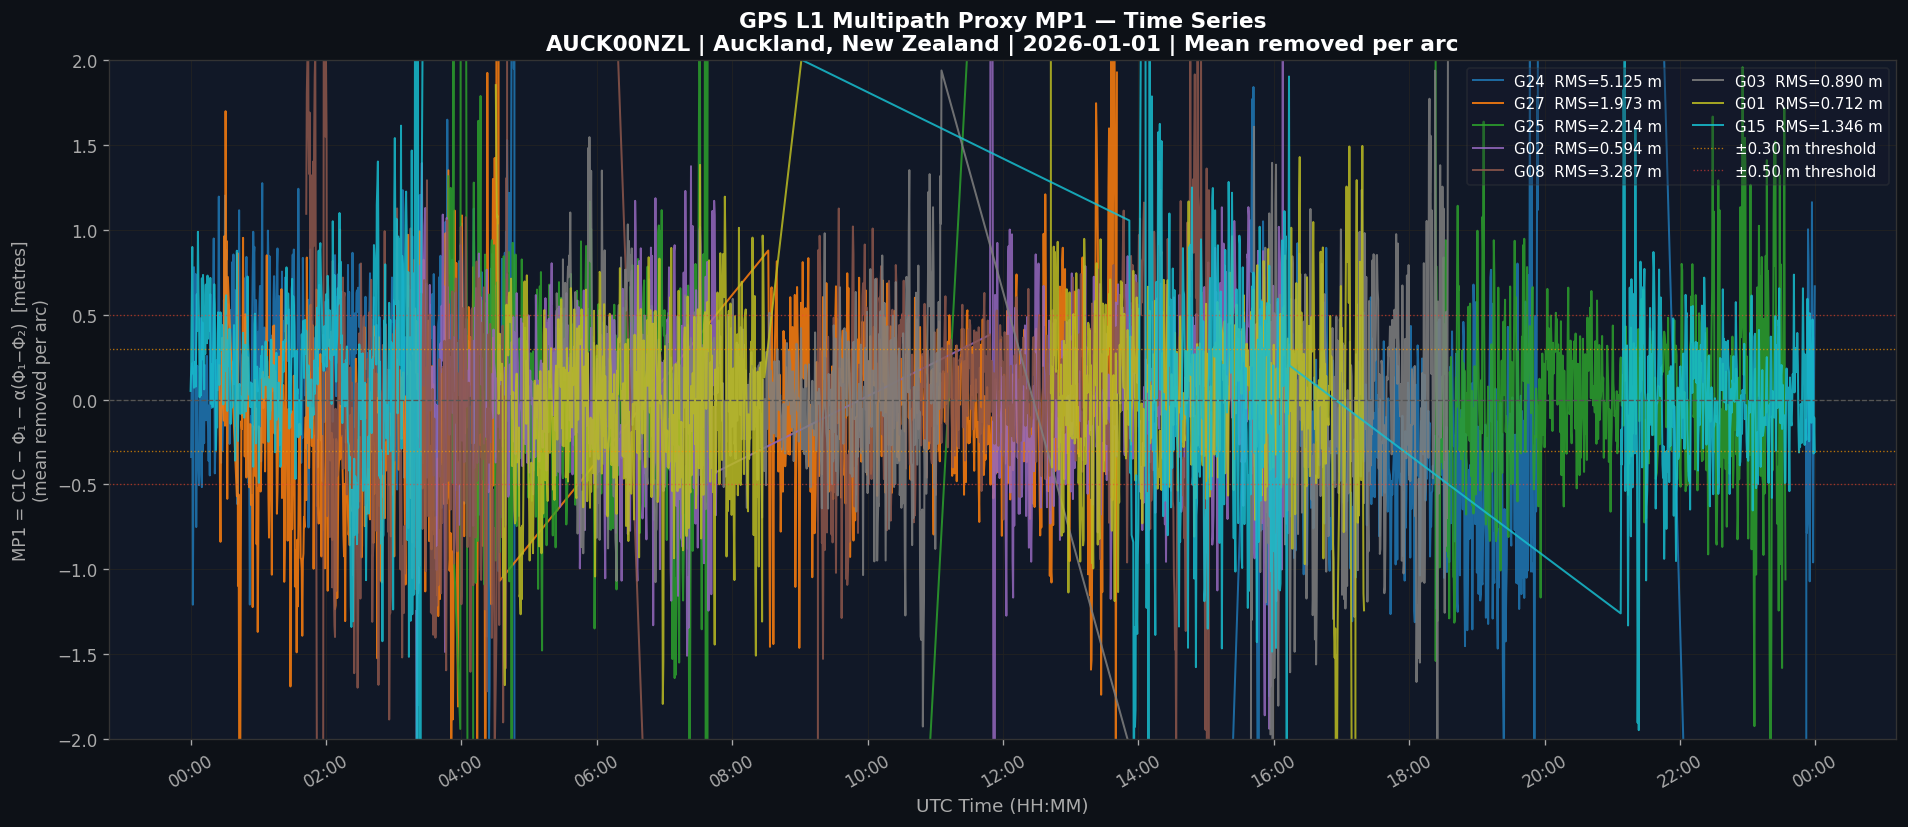

✅ Saved: output/plot1_mp1_timeseries.png

💡 Interpretation:
   • Oscillations around zero = multipath coming and going as satellite moves
   • Larger amplitude = stronger reflection in that direction
   • Orange/red dashed lines = quality thresholds
   • A slow drift (long wavelength) = poorly removed ionosphere / arc-split issue


In [24]:
# ─────────────────────────────────────────────────────────
# Step 4 — Plot 1: MP1 Time Series (Selected Satellites)
# ─────────────────────────────────────────────────────────
# Plot the 8 satellites with the most epochs (most complete arcs)
top_sats = sorted(mp1_data, key=lambda s: len(mp1_data[s][0]), reverse=True)[:8]

palette = plt.cm.tab10(np.linspace(0, 1, len(top_sats)))
sat_colors = {sat: palette[i] for i, sat in enumerate(top_sats)}

fig, ax = plt.subplots(figsize=(16, 7), facecolor='#0d1117')

#Function that apply the standard dark GNSS theme to an Axes object.
dark_style(ax)

ax.set_title(
    'GPS L1 Multipath Proxy MP1 — Time Series\n'
    'AUCK00NZL | Auckland, New Zealand | 2026-01-01 | Mean removed per arc',
    fontsize=13, fontweight='bold', color='#ffffff'
)

for sat in top_sats:
    mp1, rms1 = mp1_data[sat]
    ax.plot(
        mp1.index, mp1.values,
        color=sat_colors[sat], lw=1.2, alpha=0.85,
        label=f'{sat}  RMS={rms1:.3f} m'
    )

ax.axhline(0, color='#555555', lw=0.8, ls='--')
ax.axhline(+0.30, color='#FF9800', lw=0.8, ls=':', alpha=0.7, label='±0.30 m threshold')
ax.axhline(-0.30, color='#FF9800', lw=0.8, ls=':', alpha=0.7)
ax.axhline(+0.50, color='#F44336', lw=0.8, ls=':', alpha=0.6, label='±0.50 m threshold')
ax.axhline(-0.50, color='#F44336', lw=0.8, ls=':', alpha=0.6)

ax.set_ylabel('MP1 = C1C − Φ₁ − α(Φ₁−Φ₂)  [metres]\n(mean removed per arc)',
              color='#aaaaaa', fontsize=10)
ax.set_xlabel('UTC Time (HH:MM)', color='#aaaaaa', fontsize=11)
ax.set_ylim(-2.0, 2.0)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xticks(rotation=30, color='#aaaaaa')

# Function of dark Legend
dark_legend(ax, fontsize=9, ncol=2, loc='upper right')

plt.tight_layout()
#the folder path of the saving outputs
plt.savefig('../content/output/plot1_mp1_timeseries.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

print('✅ Saved: output/plot1_mp1_timeseries.png')
print()
print('💡 Interpretation:')
print('   • Oscillations around zero = multipath coming and going as satellite moves')
print('   • Larger amplitude = stronger reflection in that direction')
print('   • Orange/red dashed lines = quality thresholds')
print('   • A slow drift (long wavelength) = poorly removed ionosphere / arc-split issue')

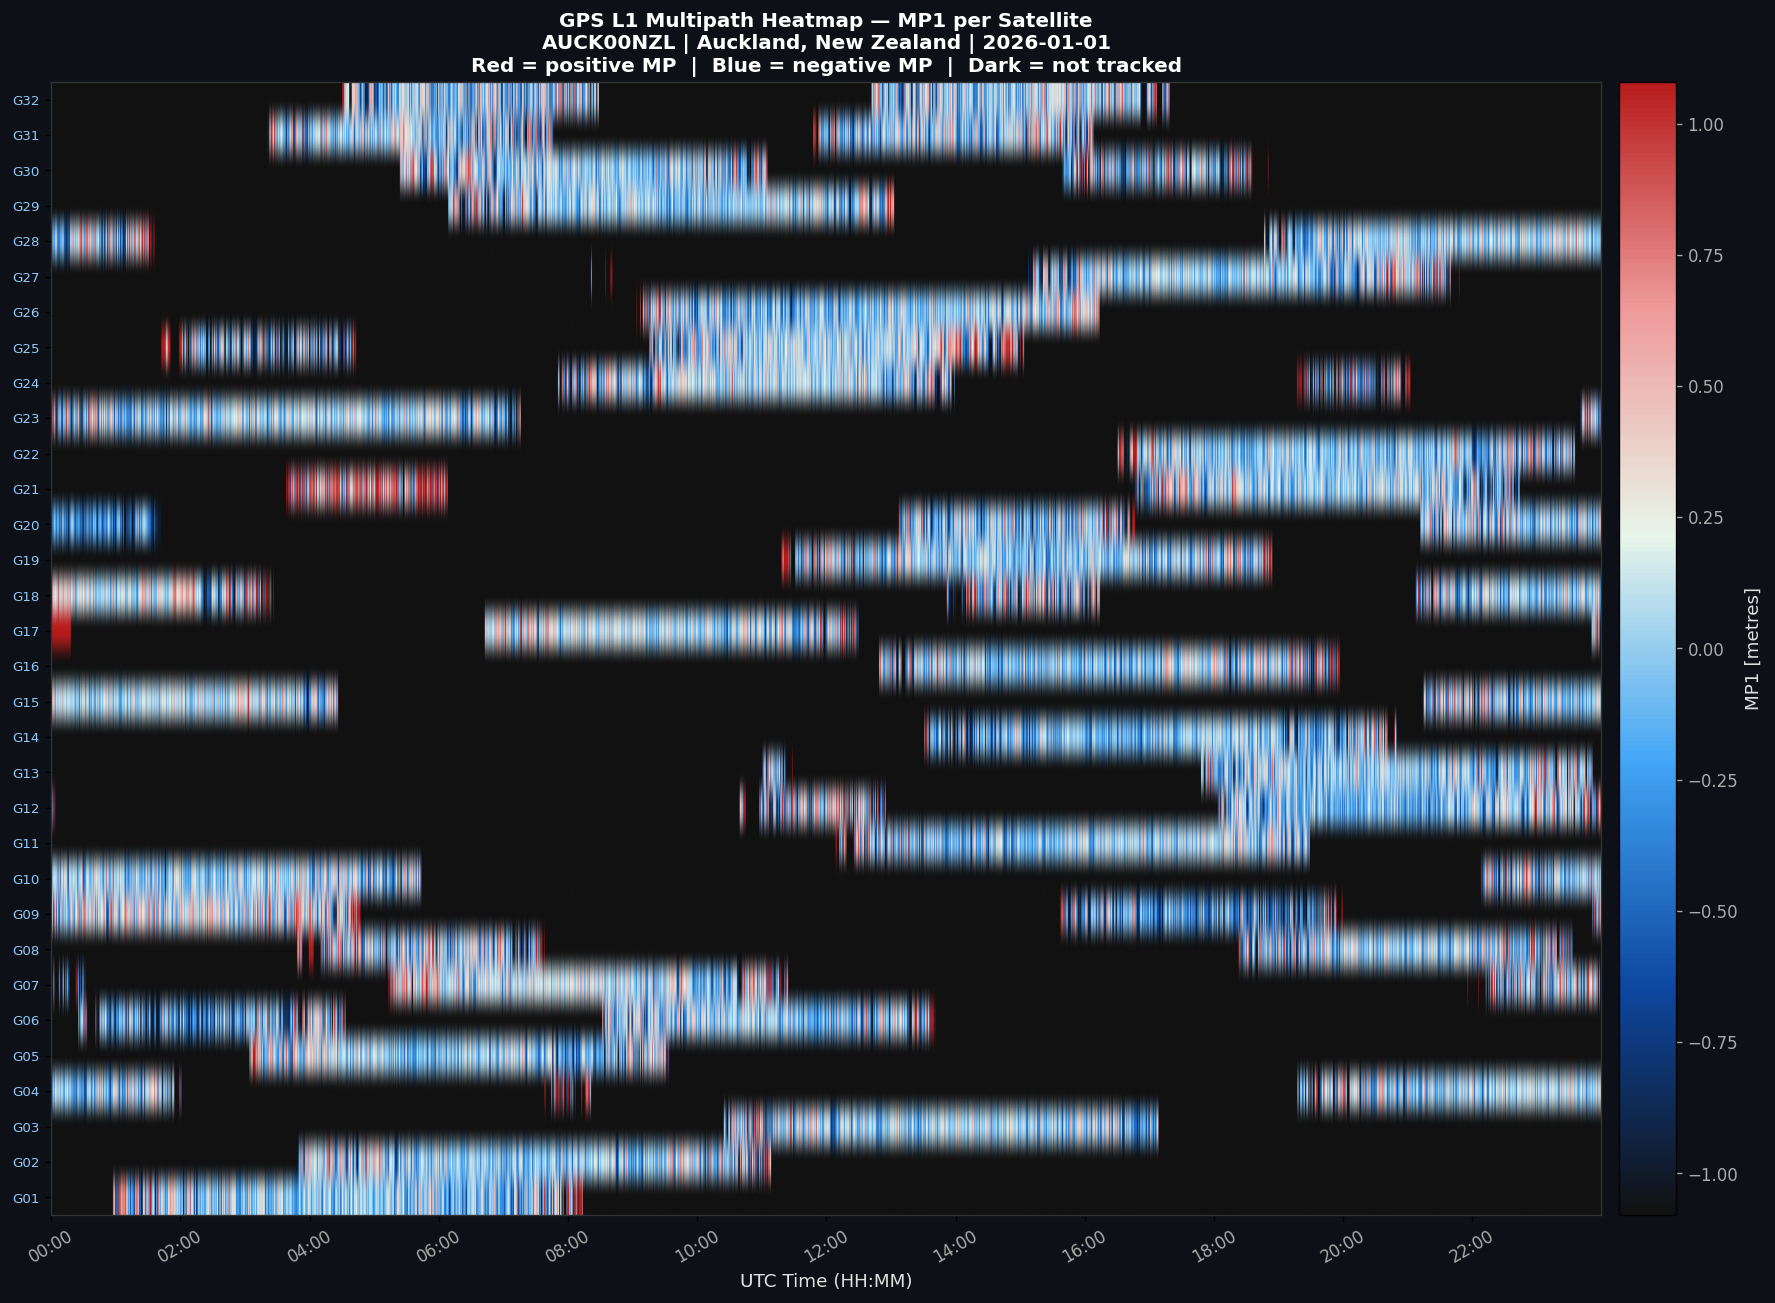

✅ Saved: output/plot2_mp1_heatmap.png

💡 Interpretation:
   • Vertical colour bands at the same UTC hour across multiple sats
     → site-specific reflector active at that time of day
   • Smooth arcs = low multipath environment
   • Abrupt colour changes = cycle slip boundaries (arc re-normalised)


In [25]:
# ─────────────────────────────────────
# Step 5 — Plot 2: MP1 Heatmap
# ─────────────────────────────────────

time_index  = pd.to_datetime(obs.time.values)
n_epochs    = len(time_index)
ordered_sats = sorted(mp1_data.keys())
n_rows       = len(ordered_sats)

# Build MP1 matrix: rows = satellites, columns = time
mp1_matrix = np.full((n_rows, n_epochs), np.nan)

for i, sat in enumerate(ordered_sats):
    mp1, _ = mp1_data[sat]

    # FIX: remove duplicate timestamps (prevents reindex error)
    mp1 = mp1.groupby(mp1.index).mean()

    mp1_matrix[i, :] = mp1.reindex(time_index).values

# Diverging colour scale
vmax = min(np.nanpercentile(np.abs(mp1_matrix), 95), 1.5)
vmax = max(vmax, 0.3)

mp1_display = np.where(np.isnan(mp1_matrix), -vmax * 4, mp1_matrix)

mp_cmap = LinearSegmentedColormap.from_list(
    'mp_div',
    ['#111111', '#0d47a1', '#42a5f5', '#e8f5e9', '#ef9a9a', '#b71c1c'],
    N=256
)

row_h  = 0.28
fig, ax = plt.subplots(figsize=(16, max(6, n_rows * row_h + 2)), facecolor='#0d1117')
ax.set_facecolor('#0d1117')

ax.imshow(
    mp1_display,
    aspect='auto',
    cmap=mp_cmap,
    vmin=-vmax, vmax=vmax,
    extent=[
        mdates.date2num(time_index[0]),
        mdates.date2num(time_index[-1]),
        -0.5, n_rows - 0.5,
    ],
    origin='upper',
)

ax.xaxis_date()

sm = plt.cm.ScalarMappable(cmap=mp_cmap, norm=plt.Normalize(vmin=-vmax, vmax=vmax))
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label('MP1 [metres]', color='#e0e0e0', fontsize=11)
cbar.ax.yaxis.set_tick_params(color='#aaaaaa')
plt.setp(cbar.ax.get_yticklabels(), color='#aaaaaa')

ax.set_yticks(range(n_rows))
ax.set_yticklabels(ordered_sats, fontsize=8, color='#90CAF9')

ax.set_title(
    'GPS L1 Multipath Heatmap — MP1 per Satellite\n'
    'AUCK00NZL | Auckland, New Zealand | 2026-01-01\n'
    'Red = positive MP  |  Blue = negative MP  |  Dark = not tracked',
    fontsize=12, fontweight='bold', color='#ffffff'
)

ax.set_xlabel('UTC Time (HH:MM)', fontsize=11, color='#e0e0e0')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))

plt.xticks(rotation=30, color='#aaaaaa')

for spine in ax.spines.values():
    spine.set_edgecolor('#333333')

plt.tight_layout()

plt.savefig('../content/output/plot2_mp1_heatmap.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())

plt.show()

print('✅ Saved: output/plot2_mp1_heatmap.png')

print()
print('💡 Interpretation:')
print('   • Vertical colour bands at the same UTC hour across multiple sats')
print('     → site-specific reflector active at that time of day')
print('   • Smooth arcs = low multipath environment')
print('   • Abrupt colour changes = cycle slip boundaries (arc re-normalised)')

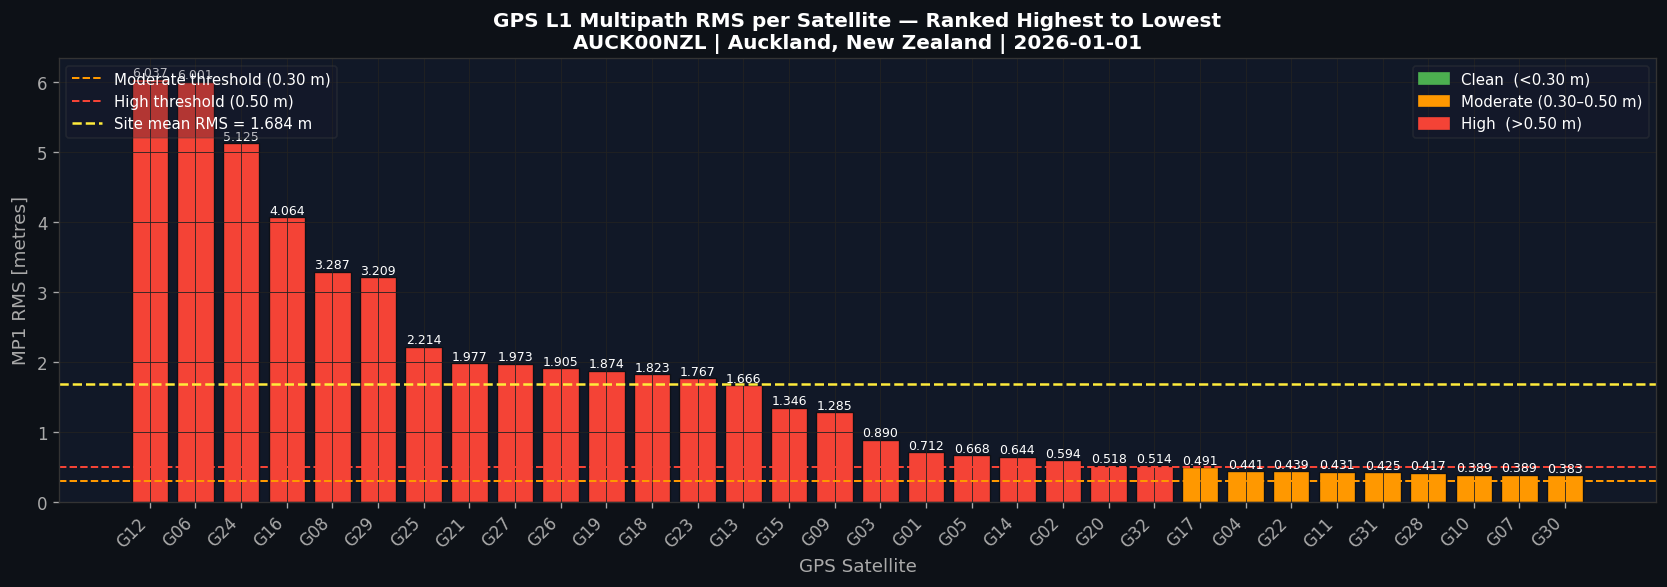

✅ Saved: output/plot3_mp1_rms_ranking.png

📊 MP1 RMS ranking:
   G12: 6.037 m  — HIGH MULTIPATH
   G06: 6.001 m  — HIGH MULTIPATH
   G24: 5.125 m  — HIGH MULTIPATH
   G16: 4.064 m  — HIGH MULTIPATH
   G08: 3.287 m  — HIGH MULTIPATH
   G29: 3.209 m  — HIGH MULTIPATH
   G25: 2.214 m  — HIGH MULTIPATH
   G21: 1.977 m  — HIGH MULTIPATH
   G27: 1.973 m  — HIGH MULTIPATH
   G26: 1.905 m  — HIGH MULTIPATH
   G19: 1.874 m  — HIGH MULTIPATH
   G18: 1.823 m  — HIGH MULTIPATH
   G23: 1.767 m  — HIGH MULTIPATH
   G13: 1.666 m  — HIGH MULTIPATH
   G15: 1.346 m  — HIGH MULTIPATH
   G09: 1.285 m  — HIGH MULTIPATH
   G03: 0.890 m  — HIGH MULTIPATH
   G01: 0.712 m  — HIGH MULTIPATH
   G05: 0.668 m  — HIGH MULTIPATH
   G14: 0.644 m  — HIGH MULTIPATH
   G02: 0.594 m  — HIGH MULTIPATH
   G20: 0.518 m  — HIGH MULTIPATH
   G32: 0.514 m  — HIGH MULTIPATH
   G17: 0.491 m  — Moderate
   G04: 0.441 m  — Moderate
   G22: 0.439 m  — Moderate
   G11: 0.431 m  — Moderate
   G31: 0.425 m  — Moderate
   G28: 0.417 m 

In [26]:
# ──────────────────────────────────────────────────────
# Step 6 — Plot 4: MP1 RMS Bar Chart (Satellite Ranking)
# ──────────────────────────────────────────────────────
rms_dict = {sat: mp1_data[sat][1] for sat in ordered_sats if mp1_data[sat][1] is not None}
rms_sorted = dict(sorted(rms_dict.items(), key=lambda x: x[1], reverse=True))

sats_s = list(rms_sorted.keys())
rms_s  = list(rms_sorted.values())

bar_colors = ['#F44336' if r > 0.5 else '#FF9800' if r > 0.3 else '#4CAF50' for r in rms_s]

fig, ax = plt.subplots(figsize=(14, 5), facecolor='#0d1117')
dark_style(ax)

bars = ax.bar(sats_s, rms_s, color=bar_colors, edgecolor='#0d1117', linewidth=0.8)

# Value labels
for bar, val in zip(bars, rms_s):
    ax.text(
        bar.get_x() + bar.get_width() / 2, val + 0.005,
        f'{val:.3f}', ha='center', va='bottom',
        fontsize=7.5, color='white'
    )

ax.axhline(0.30, color='#FF9800', ls='--', lw=1.2, label='Moderate threshold (0.30 m)')
ax.axhline(0.50, color='#F44336', ls='--', lw=1.2, label='High threshold (0.50 m)')
ax.axhline(site_rms, color='#FFEB3B', ls='--', lw=1.5,
           label=f'Site mean RMS = {site_rms:.3f} m')

ax.set_xlabel('GPS Satellite', color='#aaaaaa', fontsize=11)
ax.set_ylabel('MP1 RMS [metres]', color='#aaaaaa', fontsize=11)
ax.set_title(
    'GPS L1 Multipath RMS per Satellite — Ranked Highest to Lowest\n'
    'AUCK00NZL | Auckland, New Zealand | 2026-01-01',
    fontsize=12, fontweight='bold', color='#ffffff'
)

legend_patches = [
    Patch(color='#4CAF50', label='Clean  (<0.30 m)'),
    Patch(color='#FF9800', label='Moderate (0.30–0.50 m)'),
    Patch(color='#F44336', label='High  (>0.50 m)'),
]
legend_extra = ax.legend(handles=legend_patches, fontsize=9, loc='upper right',
                         framealpha=0.3, facecolor='#1a1a2e', edgecolor='#444444')
for t in legend_extra.get_texts(): t.set_color('white')
ax.add_artist(legend_extra)
dark_legend(ax, fontsize=9, loc='upper left')

plt.tight_layout()
plt.xticks(rotation=45, ha='right', color='#aaaaaa')

plt.tight_layout()
plt.savefig('../content/output/plot3_mp1_rms_ranking.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

print('✅ Saved: output/plot3_mp1_rms_ranking.png')
print()
print(f'📊 MP1 RMS ranking:')
for sat, rms in rms_sorted.items():
    q = 'Clean' if rms < 0.30 else 'Moderate' if rms < 0.50 else 'HIGH MULTIPATH'
    print(f'   {sat}: {rms:.3f} m  — {q}')

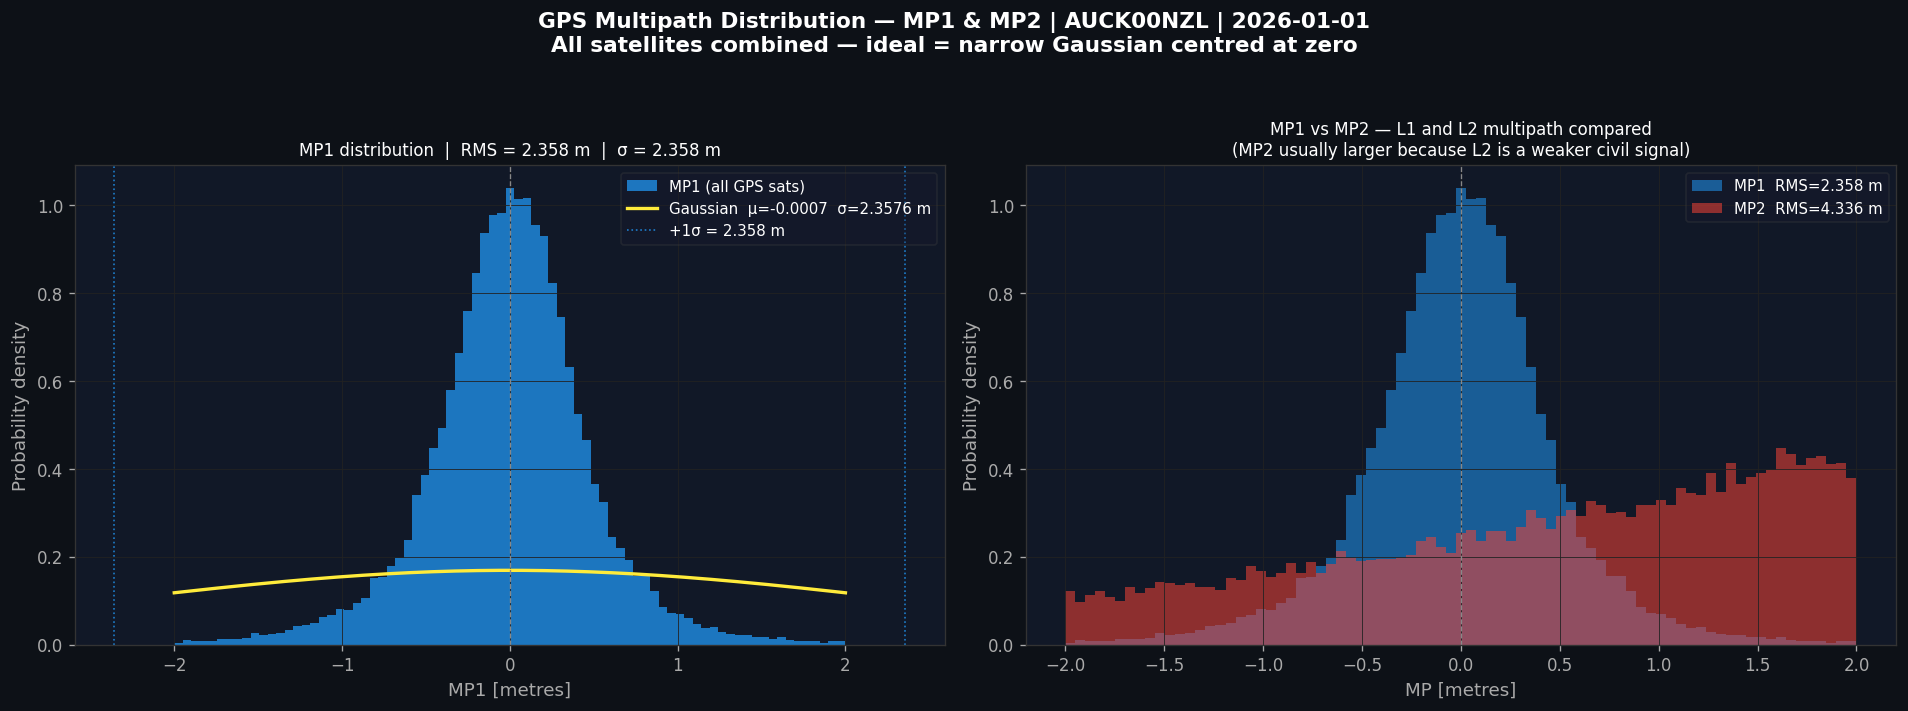

✅ Saved: output/plot4_mp_histogram.png

📊 MP1 statistics (all GPS, all arcs):
   Mean  : -0.00072 m  (should be ≈ 0 after mean removal)
   Std   : 2.358  m
   RMS   : 2.358  m
   N obs : 29,394


In [27]:
# ────────────────────────────────────────────
# Step 7 — Plot 4: MP1 Distribution Histogram
# ────────────────────────────────────────────
# Pool all MP1 values across all GPS satellites
all_mp1 = np.concatenate([mp1_data[s][0].dropna().values for s in ordered_sats])

# Statistics
mp1_mean = all_mp1.mean()
mp1_std  = all_mp1.std()
mp1_rms  = np.sqrt(np.mean(all_mp1**2))

# Also gather MP2 if available
all_mp2 = np.concatenate([mp2_data[s][0].dropna().values
                          for s in ordered_sats if s in mp2_data])

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0d1117')
fig.suptitle(
    'GPS Multipath Distribution — MP1 & MP2 | AUCK00NZL | 2026-01-01\n'
    'All satellites combined — ideal = narrow Gaussian centred at zero',
    fontsize=13, fontweight='bold', color='#ffffff'
)

for ax in axes:
    dark_style(ax)

# ─── Left: MP1 histogram ───────────────────────────────────
bins = np.linspace(-2.0, 2.0, 80)
axes[0].hist(all_mp1, bins=bins, color='#2196F3', alpha=0.75,
             density=True, edgecolor='none', label='MP1 (all GPS sats)')

# Gaussian fit
from numpy import pi as PI
x_fit = np.linspace(-2.0, 2.0, 300)
gauss = (1/(mp1_std * np.sqrt(2*PI))) * np.exp(-0.5*((x_fit - mp1_mean)/mp1_std)**2)
axes[0].plot(x_fit, gauss, color='#FFEB3B', lw=2.0,
             label=f'Gaussian  μ={mp1_mean:.4f}  σ={mp1_std:.4f} m')

axes[0].axvline(0, color='#888888', lw=0.8, ls='--')
axes[0].axvline(+mp1_std, color='#2196F3', lw=1.0, ls=':', alpha=0.8,
                label=f'+1σ = {mp1_std:.3f} m')
axes[0].axvline(-mp1_std, color='#2196F3', lw=1.0, ls=':', alpha=0.8)

axes[0].set_xlabel('MP1 [metres]', color='#aaaaaa', fontsize=11)
axes[0].set_ylabel('Probability density', color='#aaaaaa', fontsize=11)
axes[0].set_title(
    f'MP1 distribution  |  RMS = {mp1_rms:.3f} m  |  σ = {mp1_std:.3f} m',
    color='white', fontsize=10
)
dark_legend(axes[0], fontsize=9)

# ─── Right: MP1 vs MP2 comparison ──────────────────────────
if len(all_mp2) > 100:
    axes[1].hist(all_mp1, bins=bins, color='#2196F3', alpha=0.55,
                 density=True, edgecolor='none', label=f'MP1  RMS={mp1_rms:.3f} m')
    mp2_rms = np.sqrt(np.mean(all_mp2**2))
    axes[1].hist(all_mp2, bins=bins, color='#F44336', alpha=0.55,
                 density=True, edgecolor='none', label=f'MP2  RMS={mp2_rms:.3f} m')
    axes[1].set_title(
        'MP1 vs MP2 — L1 and L2 multipath compared\n'
        '(MP2 usually larger because L2 is a weaker civil signal)',
        color='white', fontsize=10
    )
    axes[1].axvline(0, color='#888888', lw=0.8, ls='--')
    axes[1].set_xlabel('MP [metres]', color='#aaaaaa', fontsize=11)
    axes[1].set_ylabel('Probability density', color='#aaaaaa', fontsize=11)
    dark_legend(axes[1], fontsize=9)
else:
    axes[1].text(0.5, 0.5, 'MP2 data not available\nfor this file',
                 ha='center', va='center', color='#aaaaaa',
                 fontsize=12, transform=axes[1].transAxes)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('../content/output/plot4_mp_histogram.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

print('✅ Saved: output/plot4_mp_histogram.png')
print()
print(f'📊 MP1 statistics (all GPS, all arcs):')
print(f'   Mean  : {mp1_mean:.5f} m  (should be ≈ 0 after mean removal)')
print(f'   Std   : {mp1_std:.3f}  m')
print(f'   RMS   : {mp1_rms:.3f}  m')
print(f'   N obs : {len(all_mp1):,}')

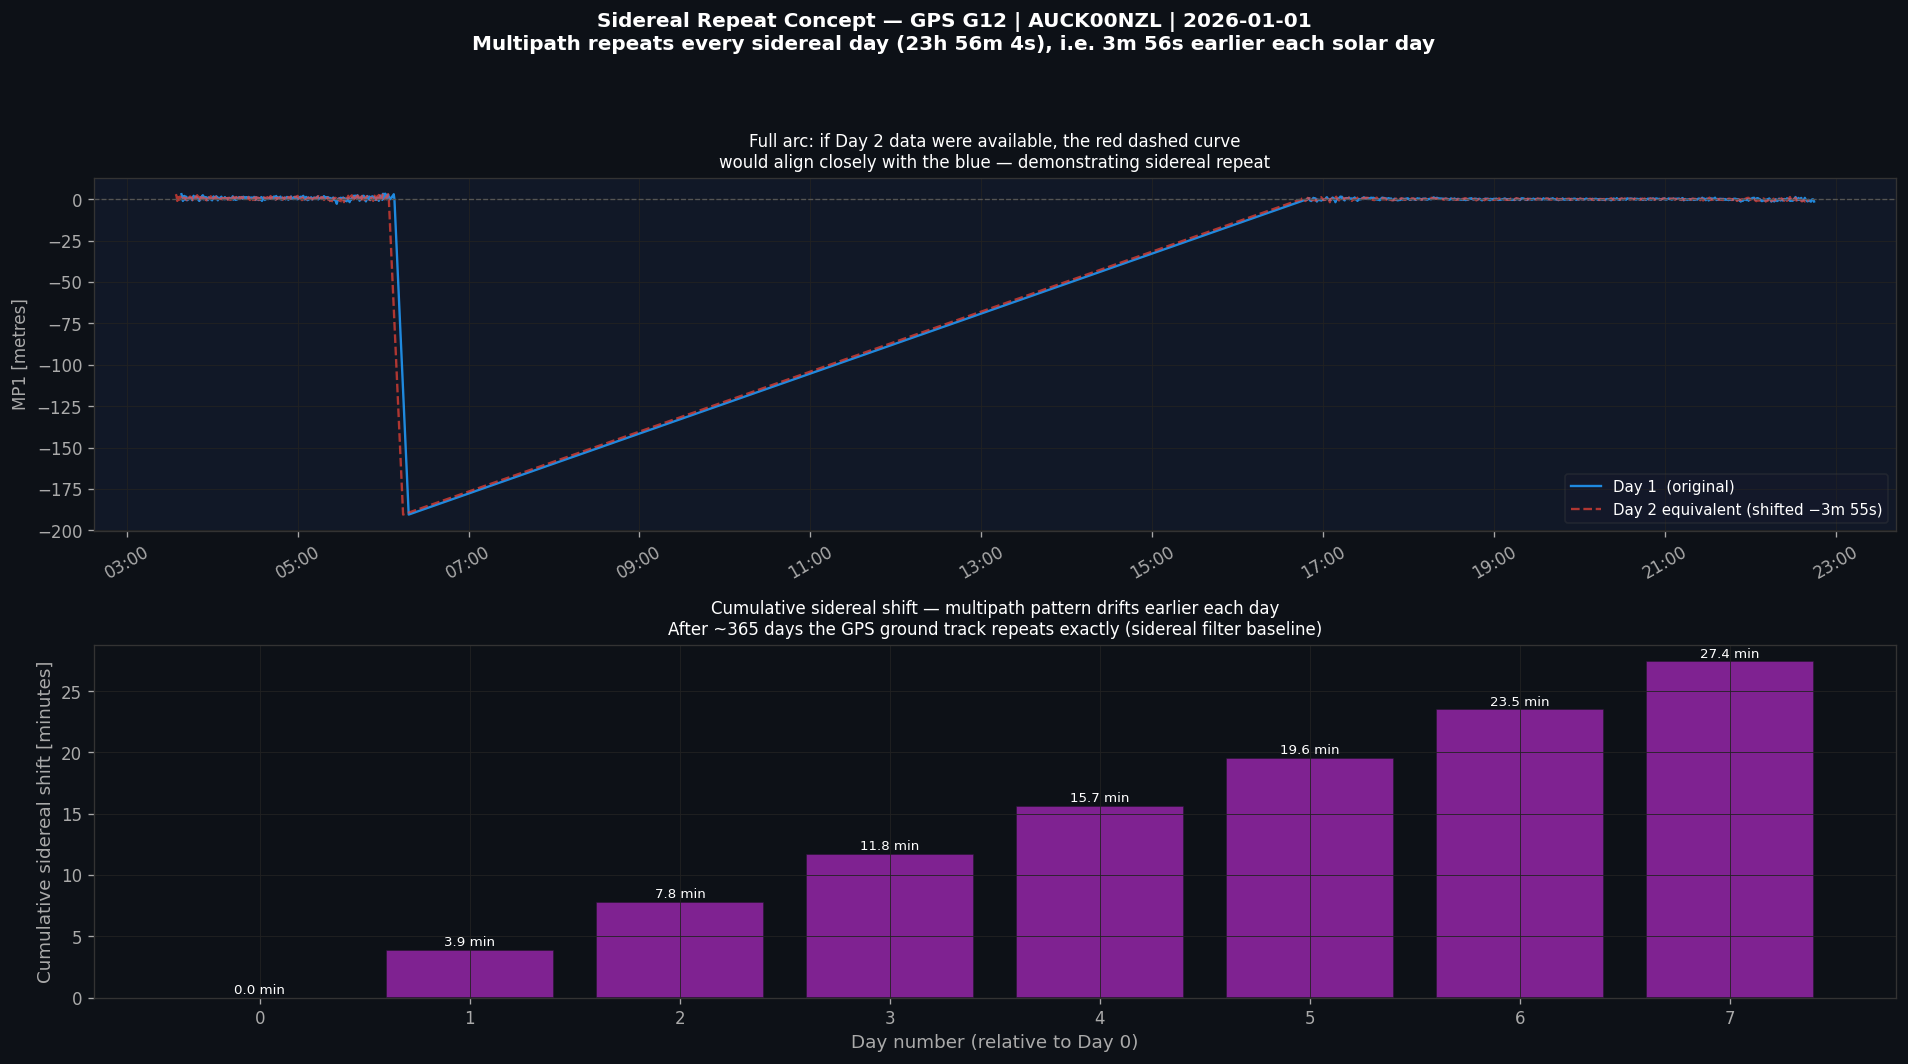

✅ Saved: output/plot5_sidereal_repeat.png

💡 Interpretation:
   • Sidereal day = 23h 56m 4.0s
   • Each day the multipath pattern shifts 3m 55s earlier
   • Sidereal filtering uses this to subtract multipath from the next day
   • Only works when the station environment does not change between days


In [29]:
# ──────────────────────────────────────
# Step 8 — Plot 5: Sidereal Repeat Check
# ──────────────────────────────────────
# Sidereal day = 86164.1 seconds = 23h 56m 4.1s
SIDEREAL_SHIFT = pd.Timedelta(seconds=86164.1)    # ≈ 23h 56m 4s
SOLAR_DAY      = pd.Timedelta(hours=24)
SHIFT_DIFF     = SOLAR_DAY - SIDEREAL_SHIFT        # ≈ 235.9 s ≈ 3m 56s per day

# Pick the GPS satellite with highest RMS (most multipath — easiest to see the repeat)
sat_demo = list(rms_sorted.keys())[0]
mp1_demo, rms_demo = mp1_data[sat_demo]

# Simulate sidereal shift: shift the same arc by SHIFT_DIFF
# In real multi-day analysis this would be the NEXT day's data shifted
mp1_shifted = mp1_demo.copy()
mp1_shifted.index = mp1_demo.index - SHIFT_DIFF

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=False, facecolor='#0d1117')
fig.suptitle(
    f'Sidereal Repeat Concept — GPS {sat_demo} | AUCK00NZL | 2026-01-01\n'
    'Multipath repeats every sidereal day (23h 56m 4s), i.e. 3m 56s earlier each solar day',
    fontsize=12, fontweight='bold', color='#ffffff'
)

for ax in axes:
    dark_style(ax)

# ─── Top: full arc ──────────────────────────────────────────
axes[0].plot(mp1_demo.index, mp1_demo.values, color='#2196F3',
             lw=1.4, alpha=0.9, label=f'Day 1  (original)')
axes[0].plot(mp1_shifted.index, mp1_shifted.values, color='#F44336',
             lw=1.4, alpha=0.7, ls='--',
             label=f'Day 2 equivalent (shifted −{SHIFT_DIFF.seconds//60}m {SHIFT_DIFF.seconds%60}s)')
axes[0].axhline(0, color='#555555', lw=0.8, ls='--')
axes[0].set_ylabel('MP1 [metres]', color='#aaaaaa', fontsize=10)
axes[0].set_title(
    f'Full arc: if Day 2 data were available, the red dashed curve\n'
    f'would align closely with the blue — demonstrating sidereal repeat',
    color='white', fontsize=10
)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[0].xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.setp(axes[0].get_xticklabels(), rotation=30, color='#aaaaaa')
dark_legend(axes[0], fontsize=9)

# ─── Bottom: sidereal info diagram ──────────────────────────
axes[1].set_facecolor('#0d1117')
days = np.arange(0, 8)
shifts_min = days * SHIFT_DIFF.seconds / 60

axes[1].bar(days, shifts_min, color='#9C27B0', alpha=0.8, edgecolor='#0d1117')
axes[1].set_xlabel('Day number (relative to Day 0)', color='#aaaaaa', fontsize=11)
axes[1].set_ylabel('Cumulative sidereal shift [minutes]', color='#aaaaaa', fontsize=11)
axes[1].set_title(
    'Cumulative sidereal shift — multipath pattern drifts earlier each day\n'
    'After ~365 days the GPS ground track repeats exactly (sidereal filter baseline)',
    color='white', fontsize=10
)
axes[1].tick_params(colors='#aaaaaa')
axes[1].grid(True, color='#222222', linewidth=0.5)
for spine in axes[1].spines.values():
    spine.set_edgecolor('#333333')

# Annotate
for i, (d, s) in enumerate(zip(days, shifts_min)):
    axes[1].text(d, s + 0.3, f'{s:.1f} min', ha='center',
                 fontsize=8, color='white')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('../content/output/plot5_sidereal_repeat.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

print('✅ Saved: output/plot5_sidereal_repeat.png')
print()
print('💡 Interpretation:')
print(f'   • Sidereal day = {SIDEREAL_SHIFT.seconds//3600}h {(SIDEREAL_SHIFT.seconds%3600)//60}m {SIDEREAL_SHIFT.seconds%60:.1f}s')
print(f'   • Each day the multipath pattern shifts {SHIFT_DIFF.seconds//60}m {SHIFT_DIFF.seconds%60}s earlier')
print(f'   • Sidereal filtering uses this to subtract multipath from the next day')
print(f'   • Only works when the station environment does not change between days')